# This code is meant to replace the combination of LAHM_analysis & LAHM_analysis_analytical

April 2021

In [2]:
# Generic resources
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
from scipy import optimize

# Local imports
import sys; sys.path.append('../')
import LAHM_library as LL

In [3]:
%matplotlib inline

In [4]:
# This is the exponential-with-time function
def test_func(t, A, t0): #first varible is the independent varible, then the subsequent are the ...
    return A*(1-np.exp(-t/t0))

In [5]:
# Instrument factors
myLAHM_Parameters = LL.LAHM_Parameters(inst_number = 10)
myLAHM_Parameters.report()

Parameters:
LAHM unit = 10
inst_factor = 0.77
exponential_prefactor = 3.43
temperature_factor = 0.238
ugbasic_offset = 3.0


In [6]:
# Graphics parameters
figwidth = 25
figheight = 12
fontsize = 12

In [7]:
# Name of the master file with all the filenames and the volumes
# filename = 'filelist_figure5.txt'
# filename = 'filelist_algae.txt'
filename = 'filelist.txt'

In [8]:
# Read in the master file
line0_list, number = LL.getline0list(filename)
# for i in range(number):
    # print(line0_list[i])

filelist.txt


In [9]:
# Run the original Schmitt analysis
myTtrace_list = LL.getgpg(line0_list, myLAHM_Parameters)
for i in range(0,number):
    myTtrace = myTtrace_list[i]
    # myTtrace.report()

From getgpg: number =  6
['2025-07-03-01-1C/run_1.txt 30', '2025-07-03-01-2B/run_1.txt 150', '2025-07-03-01-3B/run_1.txt 205', '2025-07-03-01-4B/run_1.txt 700', '2025-07-03-01-5A/run_1.txt 710', '2025-07-03-01-6/run_1.txt 1480']
From getgpg: t =  0
2025-07-03-01-1C/run_1.txt 30
From getgpg: t =  1
2025-07-03-01-2B/run_1.txt 150
From getgpg: t =  2
2025-07-03-01-3B/run_1.txt 205
From getgpg: t =  3
2025-07-03-01-4B/run_1.txt 700
From getgpg: t =  4
2025-07-03-01-5A/run_1.txt 710
From getgpg: t =  5
2025-07-03-01-6/run_1.txt 1480


2025-07-03-01-1C/run_1.txt
2025-07-03-01-2B/run_1.txt
2025-07-03-01-3B/run_1.txt
2025-07-03-01-4B/run_1.txt
2025-07-03-01-5A/run_1.txt
2025-07-03-01-6/run_1.txt


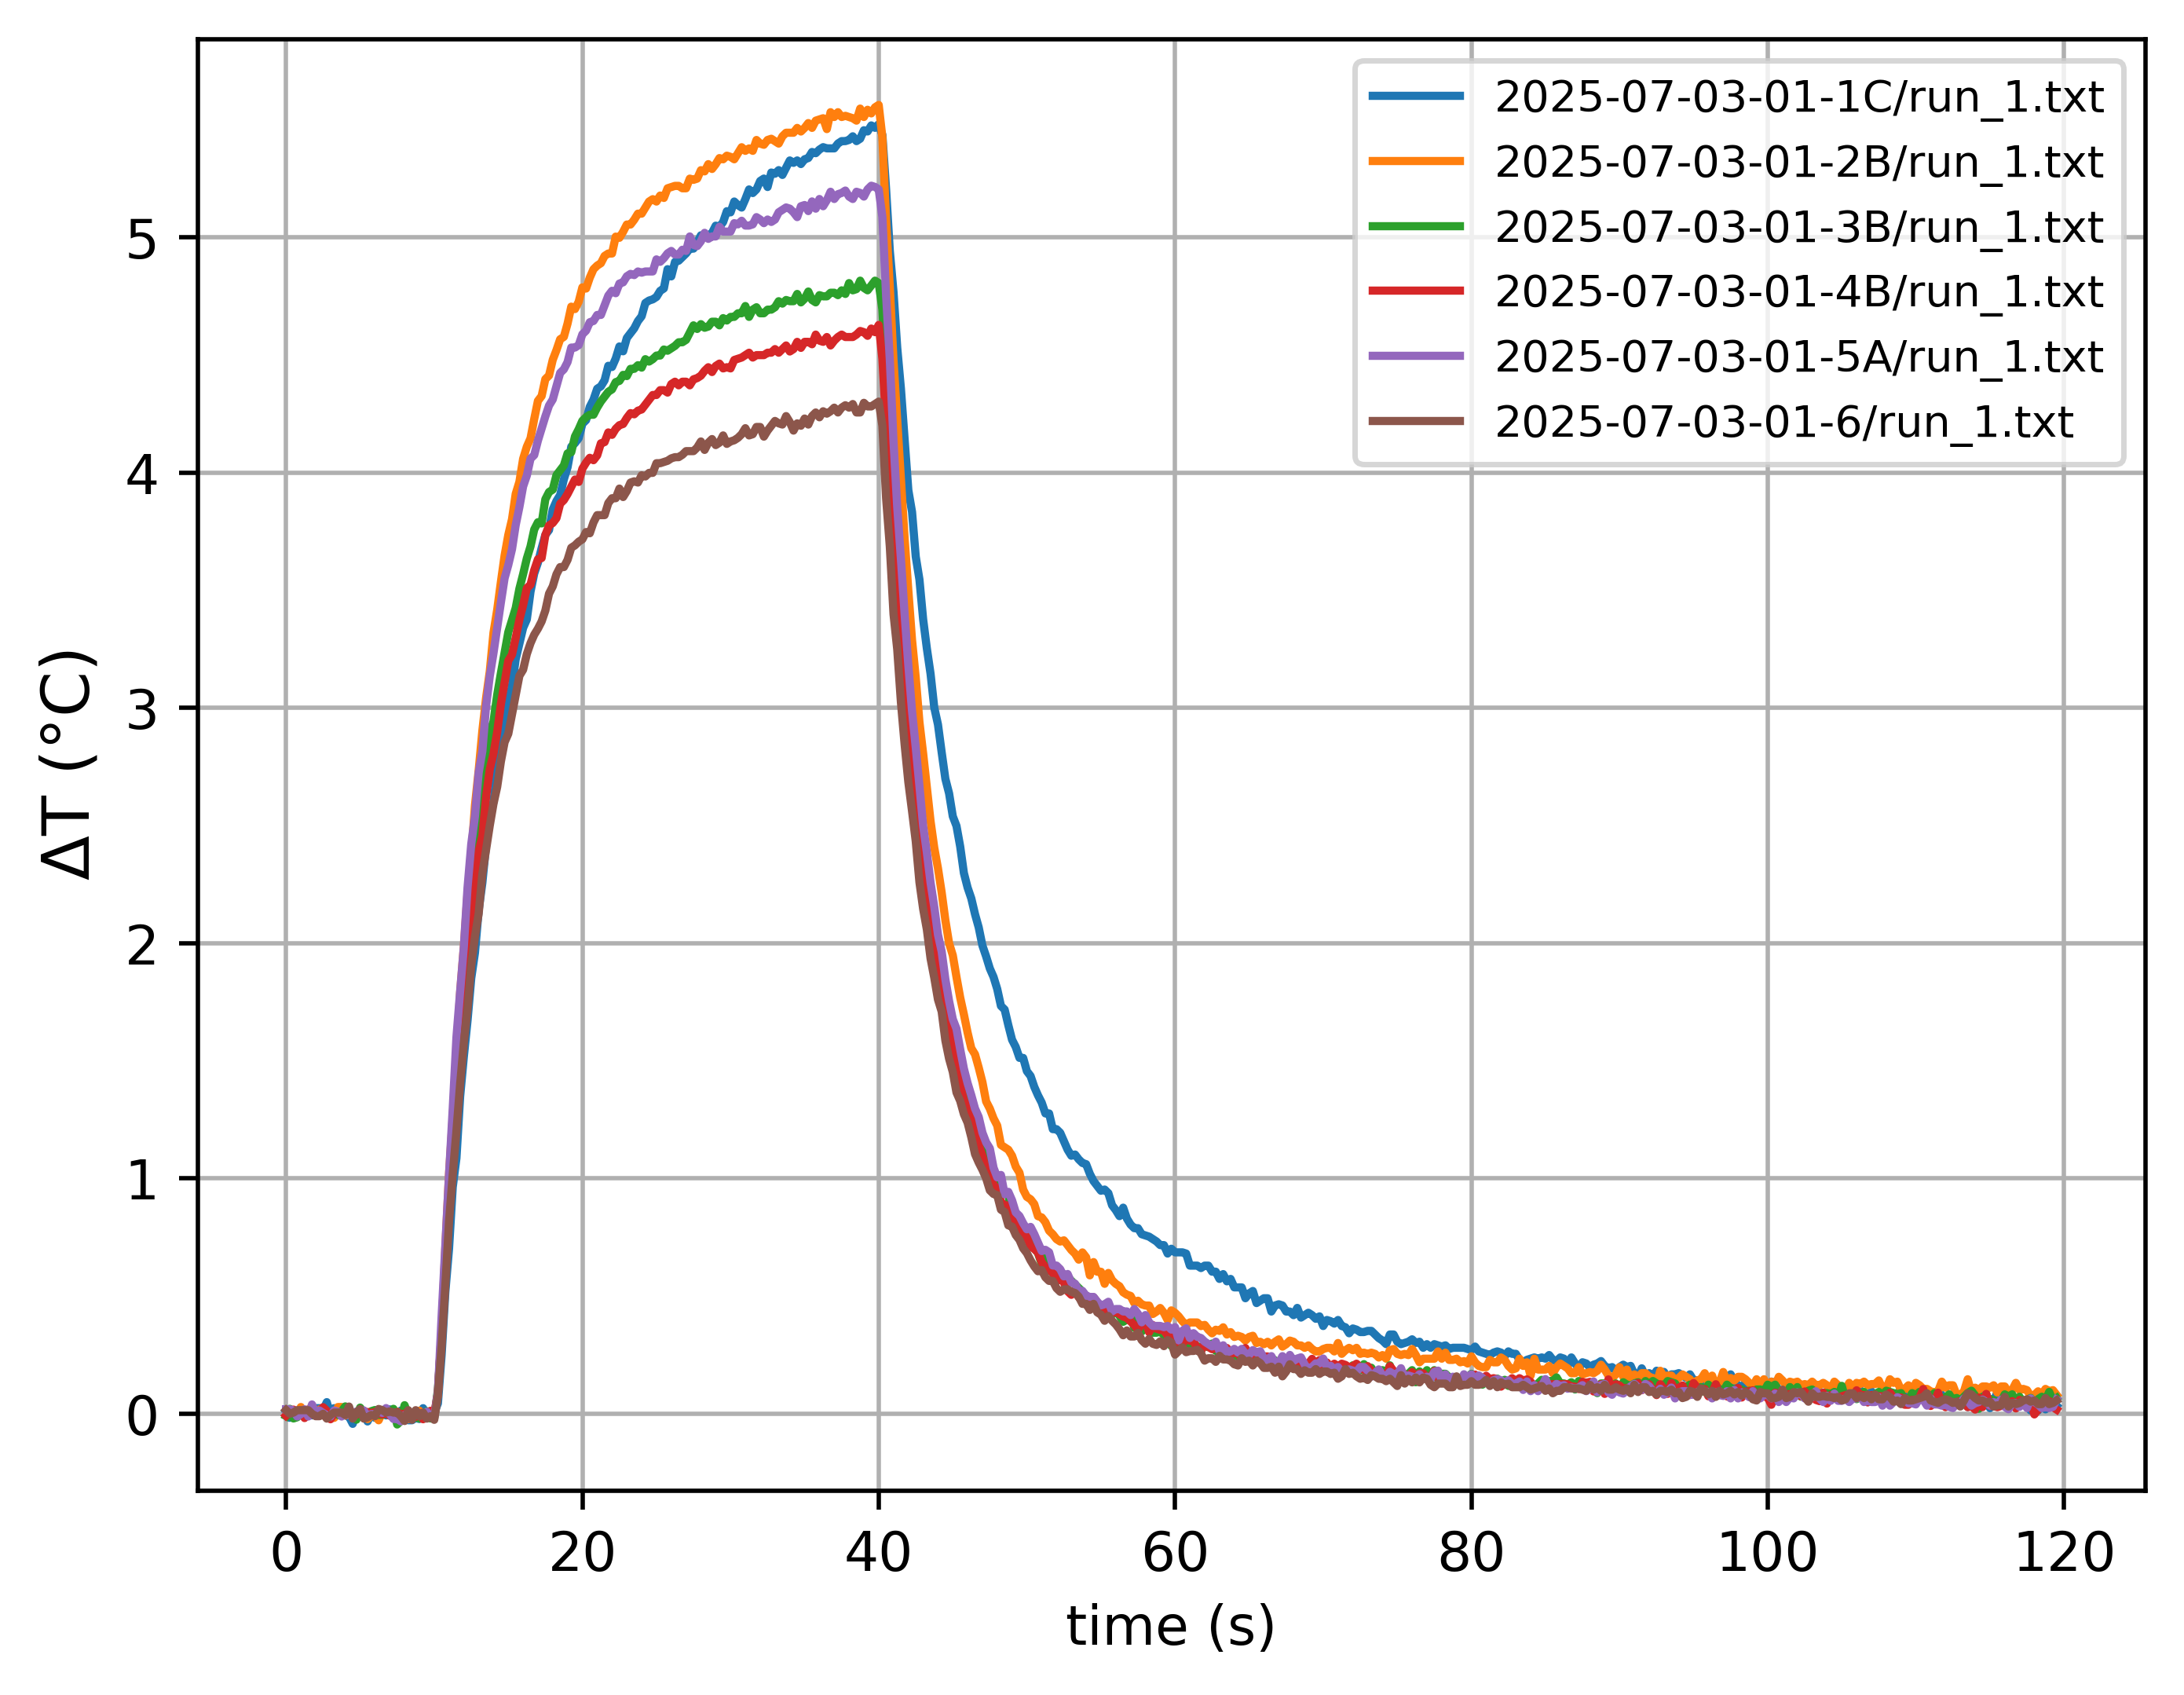

In [10]:
# Makes heating curve/Mean Temp Increase graph
# Plot all the traces
# plt.figure(figsize=(figwidth, figheight))
plt.figure(dpi=500)
mylabel_List = []
for i in range(number): 
    myTtrace = myTtrace_list[i]
   # mylabel = myTtrace.filename+', '+str(myTtrace.ugbasic)[0:4]+'$\ \mu g$'+', '+str(myTtrace.volume)[0:4]+' mL'
    mylabel = myTtrace.filename
    print(mylabel)
    mylabel_List.append(mylabel)
    plt.plot(myTtrace.time, myTtrace.Temp_av, label=mylabel) 
#plt.ylabel('Mean temp increase ($^\circ$C)')
plt.ylabel(r'$\Delta$T ($\degree$C)',fontsize=fontsize)
plt.xlabel('time (s)')
plt.legend(loc='upper right',fontsize=8)
plt.grid(True)
plt.show()

filename:  2025-07-03-01-1C/run_1.txt
volume:  30.0
ngperg:  321.3564905248701
micrograms basic:  9.640694715746102
$A(1-e^{-t/t_0})$  A=5.3918  t0=6.4542
filename:  2025-07-03-01-2B/run_1.txt
volume:  150.0
ngperg:  65.92929142730738
micrograms basic:  9.889393714096105
$A(1-e^{-t/t_0})$  A=5.4281  t0=4.5067
filename:  2025-07-03-01-3B/run_1.txt
volume:  205.0
ngperg:  37.87443259336524
micrograms basic:  7.764258681639873
$A(1-e^{-t/t_0})$  A=4.7081  t0=4.2766
filename:  2025-07-03-01-4B/run_1.txt
volume:  700.0
ngperg:  10.454265322998621
micrograms basic:  7.317985726099035
$A(1-e^{-t/t_0})$  A=4.5150  t0=4.2833
filename:  2025-07-03-01-5A/run_1.txt
volume:  710.0
ngperg:  12.443377910294343
micrograms basic:  8.834798316308984
$A(1-e^{-t/t_0})$  A=5.0950  t0=4.1403
filename:  2025-07-03-01-6/run_1.txt
volume:  1480.0
ngperg:  4.4243819684216525
micrograms basic:  6.548085313264046
$A(1-e^{-t/t_0})$  A=4.2070  t0=4.3845


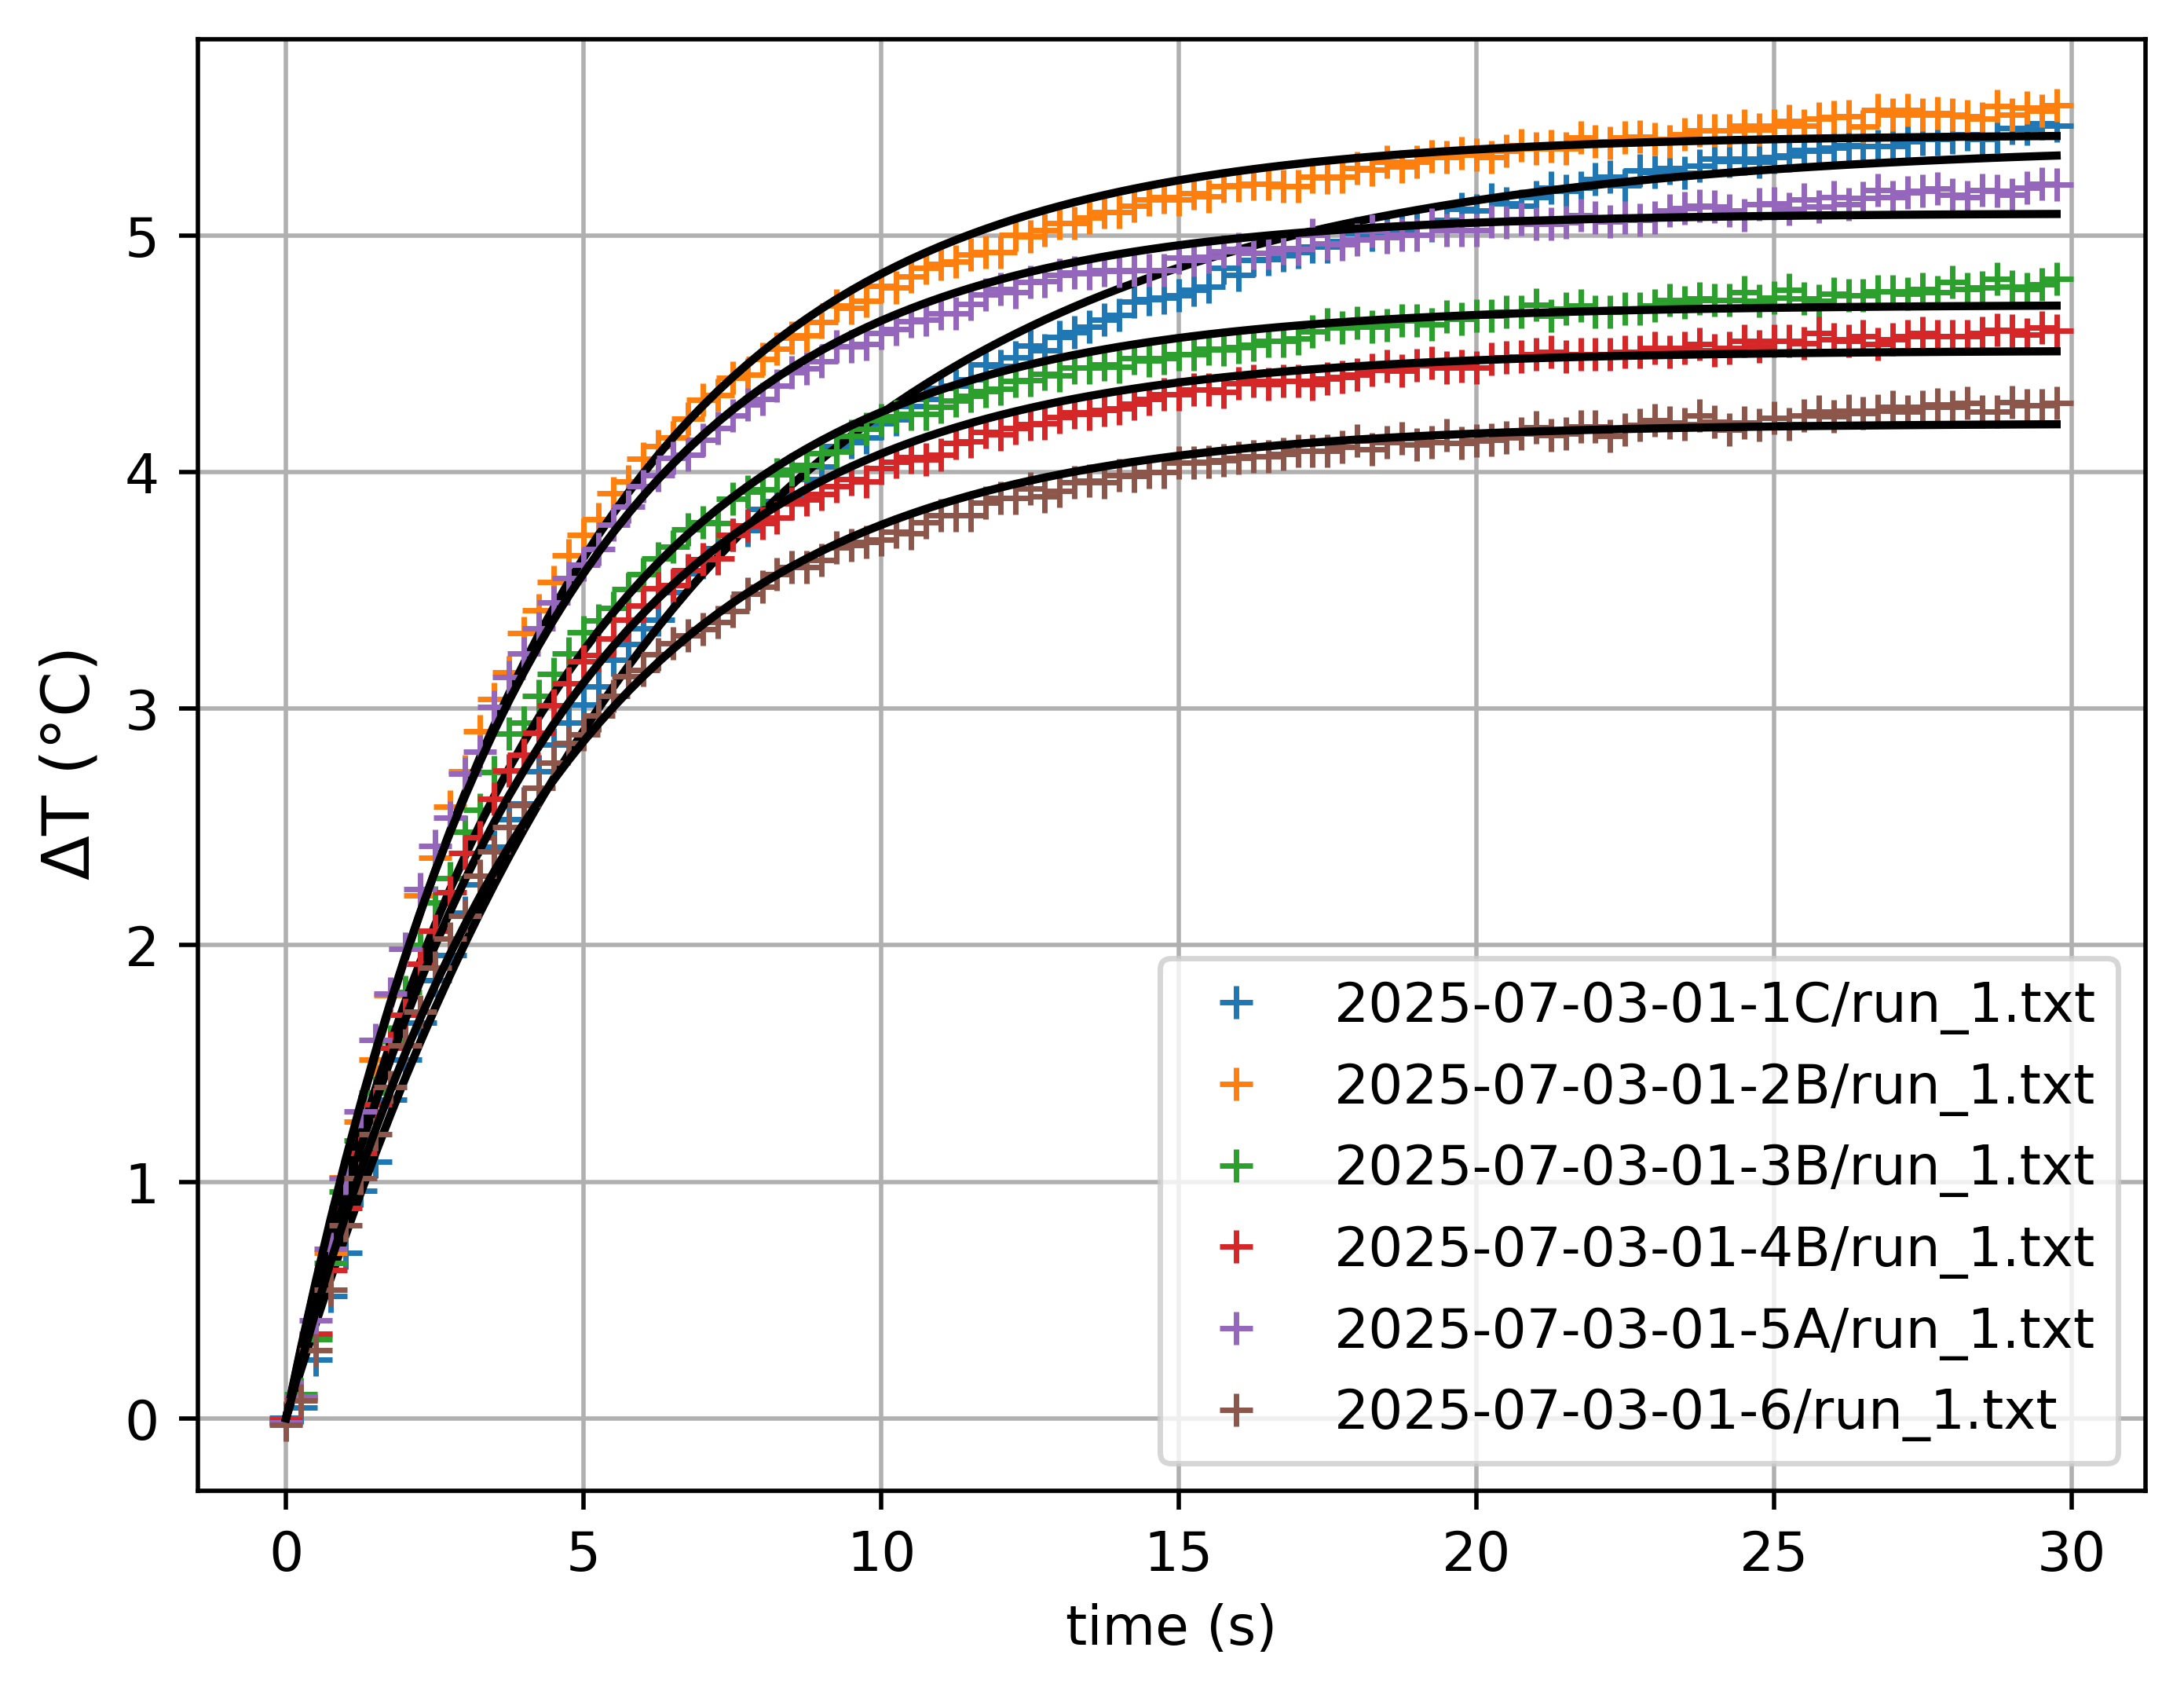

A =  [5.39186365 5.42817553 4.70816731 4.51509832 5.09509706 4.20701082]
t0 =  [6.45424011 4.50678971 4.27661235 4.28331746 4.14030303 4.3845424 ]


In [11]:
#makes Delta T graph
## Loops through file list and graphs
#True = want to see every graph
graphs = True

A_array = np.zeros(number)
t0_array = np.zeros(number)
theorylabel_List = []
plt.figure(dpi=500)
# if graphs:
#     plt.figure(dpi=200)
#     plt.show()

for i in range(number):
    myTtrace = myTtrace_list[i]
    myTtrace.report()
    
    # Extract from when it starts to rise
    Temp_expt = myTtrace.Temp_av[40:160]
    time_expt = myTtrace.time[40:160]-myTtrace.time[40]
    params, params_covariance = optimize.curve_fit(test_func, time_expt, Temp_expt, p0=[2, 3])
    A_array[i]=params[0]
    t0_array[i]=params[1]
   
    if graphs:
        theory2 = test_func(time_expt,params[0],params[1])
        exptlabel = mylabel_List[i]

        # plt.figure(dpi=200)
        plt.plot(time_expt,Temp_expt,'+',label=exptlabel)
        theorylabel = '$A(1-e^{-t/t_0})$'+'  A='+str(params[0])[0:6]+'  t0='+str(params[1])[0:6]
        print(theorylabel)
        theorylabel_List.append(theorylabel)
        plt.plot(time_expt,theory2, color= 'black')
        plt.ylabel(r'$\Delta$T ($\degree$C)',fontsize=fontsize)
        plt.xlabel('time (s)')
        plt.legend()
        plt.grid(True)
plt.show()
    

        #save figure
        #plt.savefig('bestfit.png', dpi=200)
        #plt.savefig(myTtrace.filename+'Fit.png',dpi=200)

print("A = ", A_array)
print("t0 = ",t0_array)

In [12]:
# # writes data into output.txt file
# f2 = open('output.txt', 'w')
# #header
# f2.write('file         \t \t A \t   t0\n')

# # write the data as float values with a tab between them
# for i in range(number):
#     f2.write('%s    %f    %f\n' % (myTtrace_list[i].filename, A_array[i],t0_array[i]))

# f2.close()

Text(0, 0.5, 'LAI concentration (ng/g)')

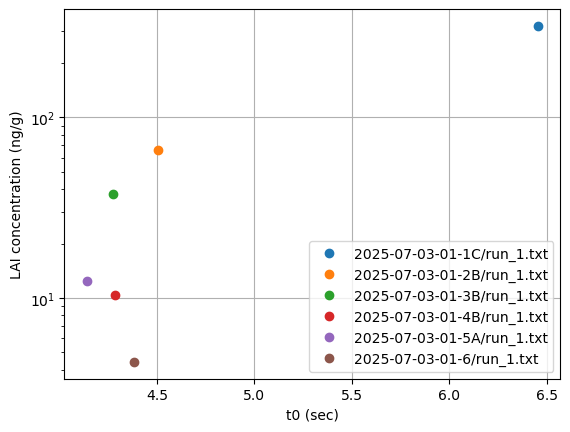

In [13]:
# Make a plot with ppb and t0
plt.figure()
for i in range(number):
    exptlabel = mylabel_List[i]
    plt.semilogy(t0_array[i],myTtrace_list[i].ngperg,'o',label=exptlabel)
plt.legend(loc='lower right')
plt.grid(True)
plt.xlabel('t0 (sec)')
plt.ylabel('LAI concentration (ng/g)')

In [14]:
# Copy micrograms into a new array "microg" from myTtrace_List
microg = np.zeros(number)
for i in range(number):
    print(myTtrace_list[i].ugbasic)
    microg[i] = myTtrace_list[i].ugbasic

# Print in the order they come
print("microg before sorting = ",microg)

# Find the indices of the microgram array in ascending order
sort_index = np.argsort(microg); print('Microgram indices in increasing order =', sort_index)

# Make new arrays of Schmitt's micrograms and A-values, in ascending order of micrograms
microg_sorted = microg[sort_index]; print("microg after sorting = ",microg_sorted)
A_array_sorted = A_array[sort_index]; print("A-values after sorting = ",A_array_sorted)

9.640694715746102
9.889393714096105
7.764258681639873
7.317985726099035
8.834798316308984
6.548085313264046
microg before sorting =  [9.64069472 9.88939371 7.76425868 7.31798573 8.83479832 6.54808531]
Microgram indices in increasing order = [5 3 2 4 0 1]
microg after sorting =  [6.54808531 7.31798573 7.76425868 8.83479832 9.64069472 9.88939371]
A-values after sorting =  [4.20701082 4.51509832 4.70816731 5.09509706 5.39186365 5.42817553]


6
fit order =  2
p =  [ 0.33181803 -0.52472945  2.89387134]


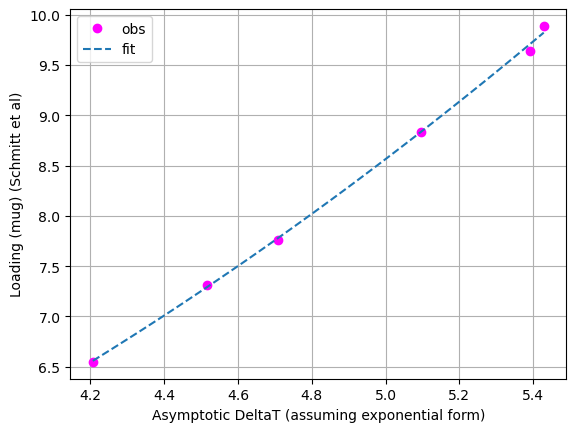

t0 ranges from  4.140303025623443 6.4542401072757345


In [15]:
# Examining correlation between A and Schmitt's micrograms
print(number)
if number > 2: 
    
    # Plot A values as a function of Schmitt's values
    # plt.figure(figsize=(figwidth, figheight))
    plt.figure()
    plt.plot(A_array_sorted, microg_sorted, 'o', color= 'magenta', label='obs')
    plt.grid(True)
    
    # Do a fit
    maxorder = 2
    if number > 2:
        fit_order = np.min((maxorder,number)); print('fit order = ',fit_order)
        p = np.polyfit(A_array_sorted, microg_sorted, fit_order); print('p = ',p)
        A_dense = np.linspace(np.min(A_array), np.max(A_array))
        microg_polyval = np.polyval(p, A_dense)
        plt.plot(A_dense, microg_polyval, '--',label='fit')
        plt.ylabel('Loading (mug) (Schmitt et al)') 
        plt.xlabel('Asymptotic DeltaT (assuming exponential form)')
    plt.legend()
    plt.show()
    
    print('t0 ranges from ', np.min(t0_array),np.max(t0_array))

In [16]:
#making sure we aren't crazy
print(A_array_sorted)
print('i  loading from A  Schmitts loading')

LoadingFromA = p[2] + p[1]* A_array_sorted + p[0]*A_array_sorted**2
for i in range(number):
    print(i, LoadingFromA[i], microg_sorted[i])
# loading as calucalted from A and Schmitt's loading agree, telling us that asymptotic A is a good proxy for t[160] (see LAHM_library) for the same material

[4.20701082 4.51509832 4.70816731 5.09509706 5.39186365 5.42817553]
i  loading from A  Schmitts loading
0 6.559156256441309 6.548085313264046
1 7.2891460645317006 7.317985726099035
2 7.778714246230345 7.764258681639873
3 8.834324540172098 8.834798316308984
4 9.71127966377368 9.640694715746102
5 9.822595696005035 9.889393714096105


fit order =  2
p =  [-0.01864077  0.67881596  0.5566184 ]


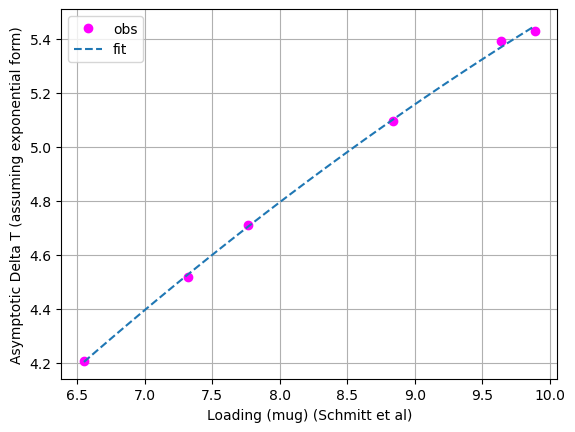

t0 ranges from  4.140303025623443 6.4542401072757345


In [17]:
# Examining correlation between A and Schmitt's micrograms

if number > 2: 
    
    # Plot A values as a function of Schmitt's values
    # plt.figure(figsize=(figwidth, figheight))
    plt.plot(microg_sorted, A_array_sorted,'o', color= 'magenta', label='obs')
    plt.grid(True)
    
    # Do a fit
    maxorder = 2
    if number > 2:
        fit_order = np.min((maxorder,number)); print('fit order = ',fit_order)
        p = np.polyfit(microg_sorted, A_array_sorted,fit_order); print('p = ',p)
        microg_dense = np.linspace(np.min(microg),np.max(microg))
        A_polyval = np.polyval(p,microg_dense)
        plt.plot(microg_dense,A_polyval,'--',label='fit')
        plt.xlabel('Loading (mug) (Schmitt et al)') 
        plt.ylabel('Asymptotic Delta T (assuming exponential form)')
    plt.legend()
    plt.show()
    
    print('t0 ranges from ', np.min(t0_array),np.max(t0_array))